Contexte

Le défaut de paiement constitue un enjeu majeur pour les institutions financières. Lorsqu'une banque accorde une carte de crédit à un client, elle prend le risque que celui-ci ne rembourse pas les sommes empruntées. Une mauvaise évaluation de ce risque peut entraîner des pertes financières importantes. Il est donc essentiel de disposer d'outils capables d'identifier les clients susceptibles de faire défaut avant que celui-ci ne survienne.

Problématique

Dans ce projet, nous nous intéressons à la prédiction du défaut de paiement de clients détenteurs d'une carte de crédit. À partir d'informations démographiques, financières et comportementales, l'objectif est de déterminer si un client effectuera ou non un défaut de paiement le mois suivant.

Objectif

Ce problème est formulé comme une tâche de classification binaire supervisée. L'objectif est de comparer plusieurs modèles de machine learning afin d'identifier celui offrant les meilleures performances prédictives pour ce problème.

Pour ne pas avoir de problèmes lors des imports des fonctions dans les fichiers du dossier src

In [42]:
%cd c:\Users\utcpret\Documents\GI04\AI28\Tps\Project

c:\Users\utcpret\Documents\GI04\AI28\Tps\Project


In [43]:
# WARNINGS
import warnings
warnings.filterwarnings('ignore')

# NUMPY
import numpy as np

# STATS
import scipy.stats as stats
from scipy.stats import norm, skew

# MATPLOTLIB
import matplotlib as mlp
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight') 

# PANDAS
import pandas as pd 
pd.set_option("display.max_rows", None, "display.max_columns", None) 

# SEABORN
import seaborn as sns

# SCIKIT-LEARN: SELECTION DE VARIABLES

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

# SCIKIT-LEARN: PRE-PROCESSING
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder # Encodage des variables catégorielles ordinales
from sklearn.preprocessing import LabelBinarizer, OneHotEncoder # Encodage des variables catégorielles nominales
from sklearn.preprocessing import StandardScaler # Normalisation des variables numériques
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer # Imputation
from sklearn.impute import KNNImputer 

# SCIKIT-LEARN: MODELES
from sklearn.linear_model import LogisticRegression

# SCIKIT-LEARN: VALIDATION CROISEE + OPTIMISATION
from sklearn.model_selection import train_test_split # Séparer en données train et test
from sklearn.model_selection import cross_val_score # Validation croisée pour comparison entre modèles
from sklearn.model_selection import validation_curve # Courbe de validation : visulaisr des scores lors du choix d'un hyper-paramètre
from sklearn.model_selection import GridSearchCV # Tester plusieurs hyper-paramètres
from sklearn.model_selection import learning_curve # Courbe d'apprentissage : visualisation des scores du train et du validation sets en fonction des quanitiés des données
 
## EVALUATION
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score


# SCHIKIT-LEARN: PIPELINE AND TRANSFORMATEURll
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

# Fontions 
from src.preprocessing import build_logistic_preprocessor,build_robust_preprocessor
from src.evaluation import train_and_evaluate, plot_confusion_matrix


Analyse Exploratoire de Données (AED)

In [44]:
! pip install xlrd

In [45]:
data = pd.read_excel('data/default of credit card clients.xls', header=1)
df = data.copy()

In [46]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [47]:
df.tail()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,30000,50000,1,2,1,46,0,0,0,0,0,0,47929,48905,49764,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [48]:
df.shape

(30000, 25)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [50]:
df.columns.values

array(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
       'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
       'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5',
       'PAY_AMT6', 'default payment next month'], dtype=object)

In [51]:

# Résumé statistique des variables
print(df.dtypes)
df.describe()

ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


Description des variables

- Limit_Bal : montant du crédit accordé, variable continue
- sex: 1 (homme), 2 (femme) => variable catégorielle
- Education : 1 = études supérieures ; 2 = études universitaires ; 3 = études secondaires ; 4 = autres => variable catégorielle
- Marriage : 1 = marié(e) ; 2 = célibataire ; 3 = autres => variable catégorielle
- Age : en années, variable continue 
- Pay_0 à Pay_6 : état du remboursement des paiements mensuels antérieurs ( de Septembre à Avril 2005) => : -1 = paiement à l’échéance ; 1 = retard de paiement d’un mois ; 2 = retard de paiement de deux mois. Variables continues
- Bill_Amt1 à Bill_Amt5 : montant de la facture en $ => variable continue
- Pay_Amt1 à Pay_Amt6 : montant du paiement précédent en $ => variable continue
- default payment next month : variable cible vaut 1(oui) et 0(non) => defaut de paiement, variable binaire discrète. 

In [ ]:
# Liste des colonnes d'historique de paiement
cols_pay = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Boucle pour afficher les pourcentages de chaque colonne
for col in cols_pay:
    print(f"\n--- Parts des modalités pour {col} (en %) ---")
    # multiplié par 100 pour avoir une lecture directe en pourcentage
    print((df[col].value_counts(normalize=True) * 100).round(2))
    nb_moins_deux = (df[cols_pay] == -2).sum()

print("Nombre d'occurrences de la modalité -2 :")
print(nb_moins_deux)

Nombre d'occurrences de la modalité -2 :
PAY_0    2759
PAY_2    3782
PAY_3    4085
PAY_4    4348
PAY_5    4546
PAY_6    4895
dtype: int64


Description de la variable d'intérêt

In [53]:
df['default payment next month'].describe()
df['default payment next month'].value_counts()
df['default payment next month'].value_counts(normalize=True)


default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

On remarque que le dataset est très déséquilibré avec uniquement 22% des variables pour la classe 1 (défaut de paiement)

In [54]:
target = df['default payment next month']
var_explicatives = df.drop('default payment next month',axis=1)

In [55]:
# Vérifier l'existence des duplications d'exemples 
duplicate_df = df[df.duplicated()]
duplicate_df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month


Text(0.5, 1.0, 'Matrice de corrélation')

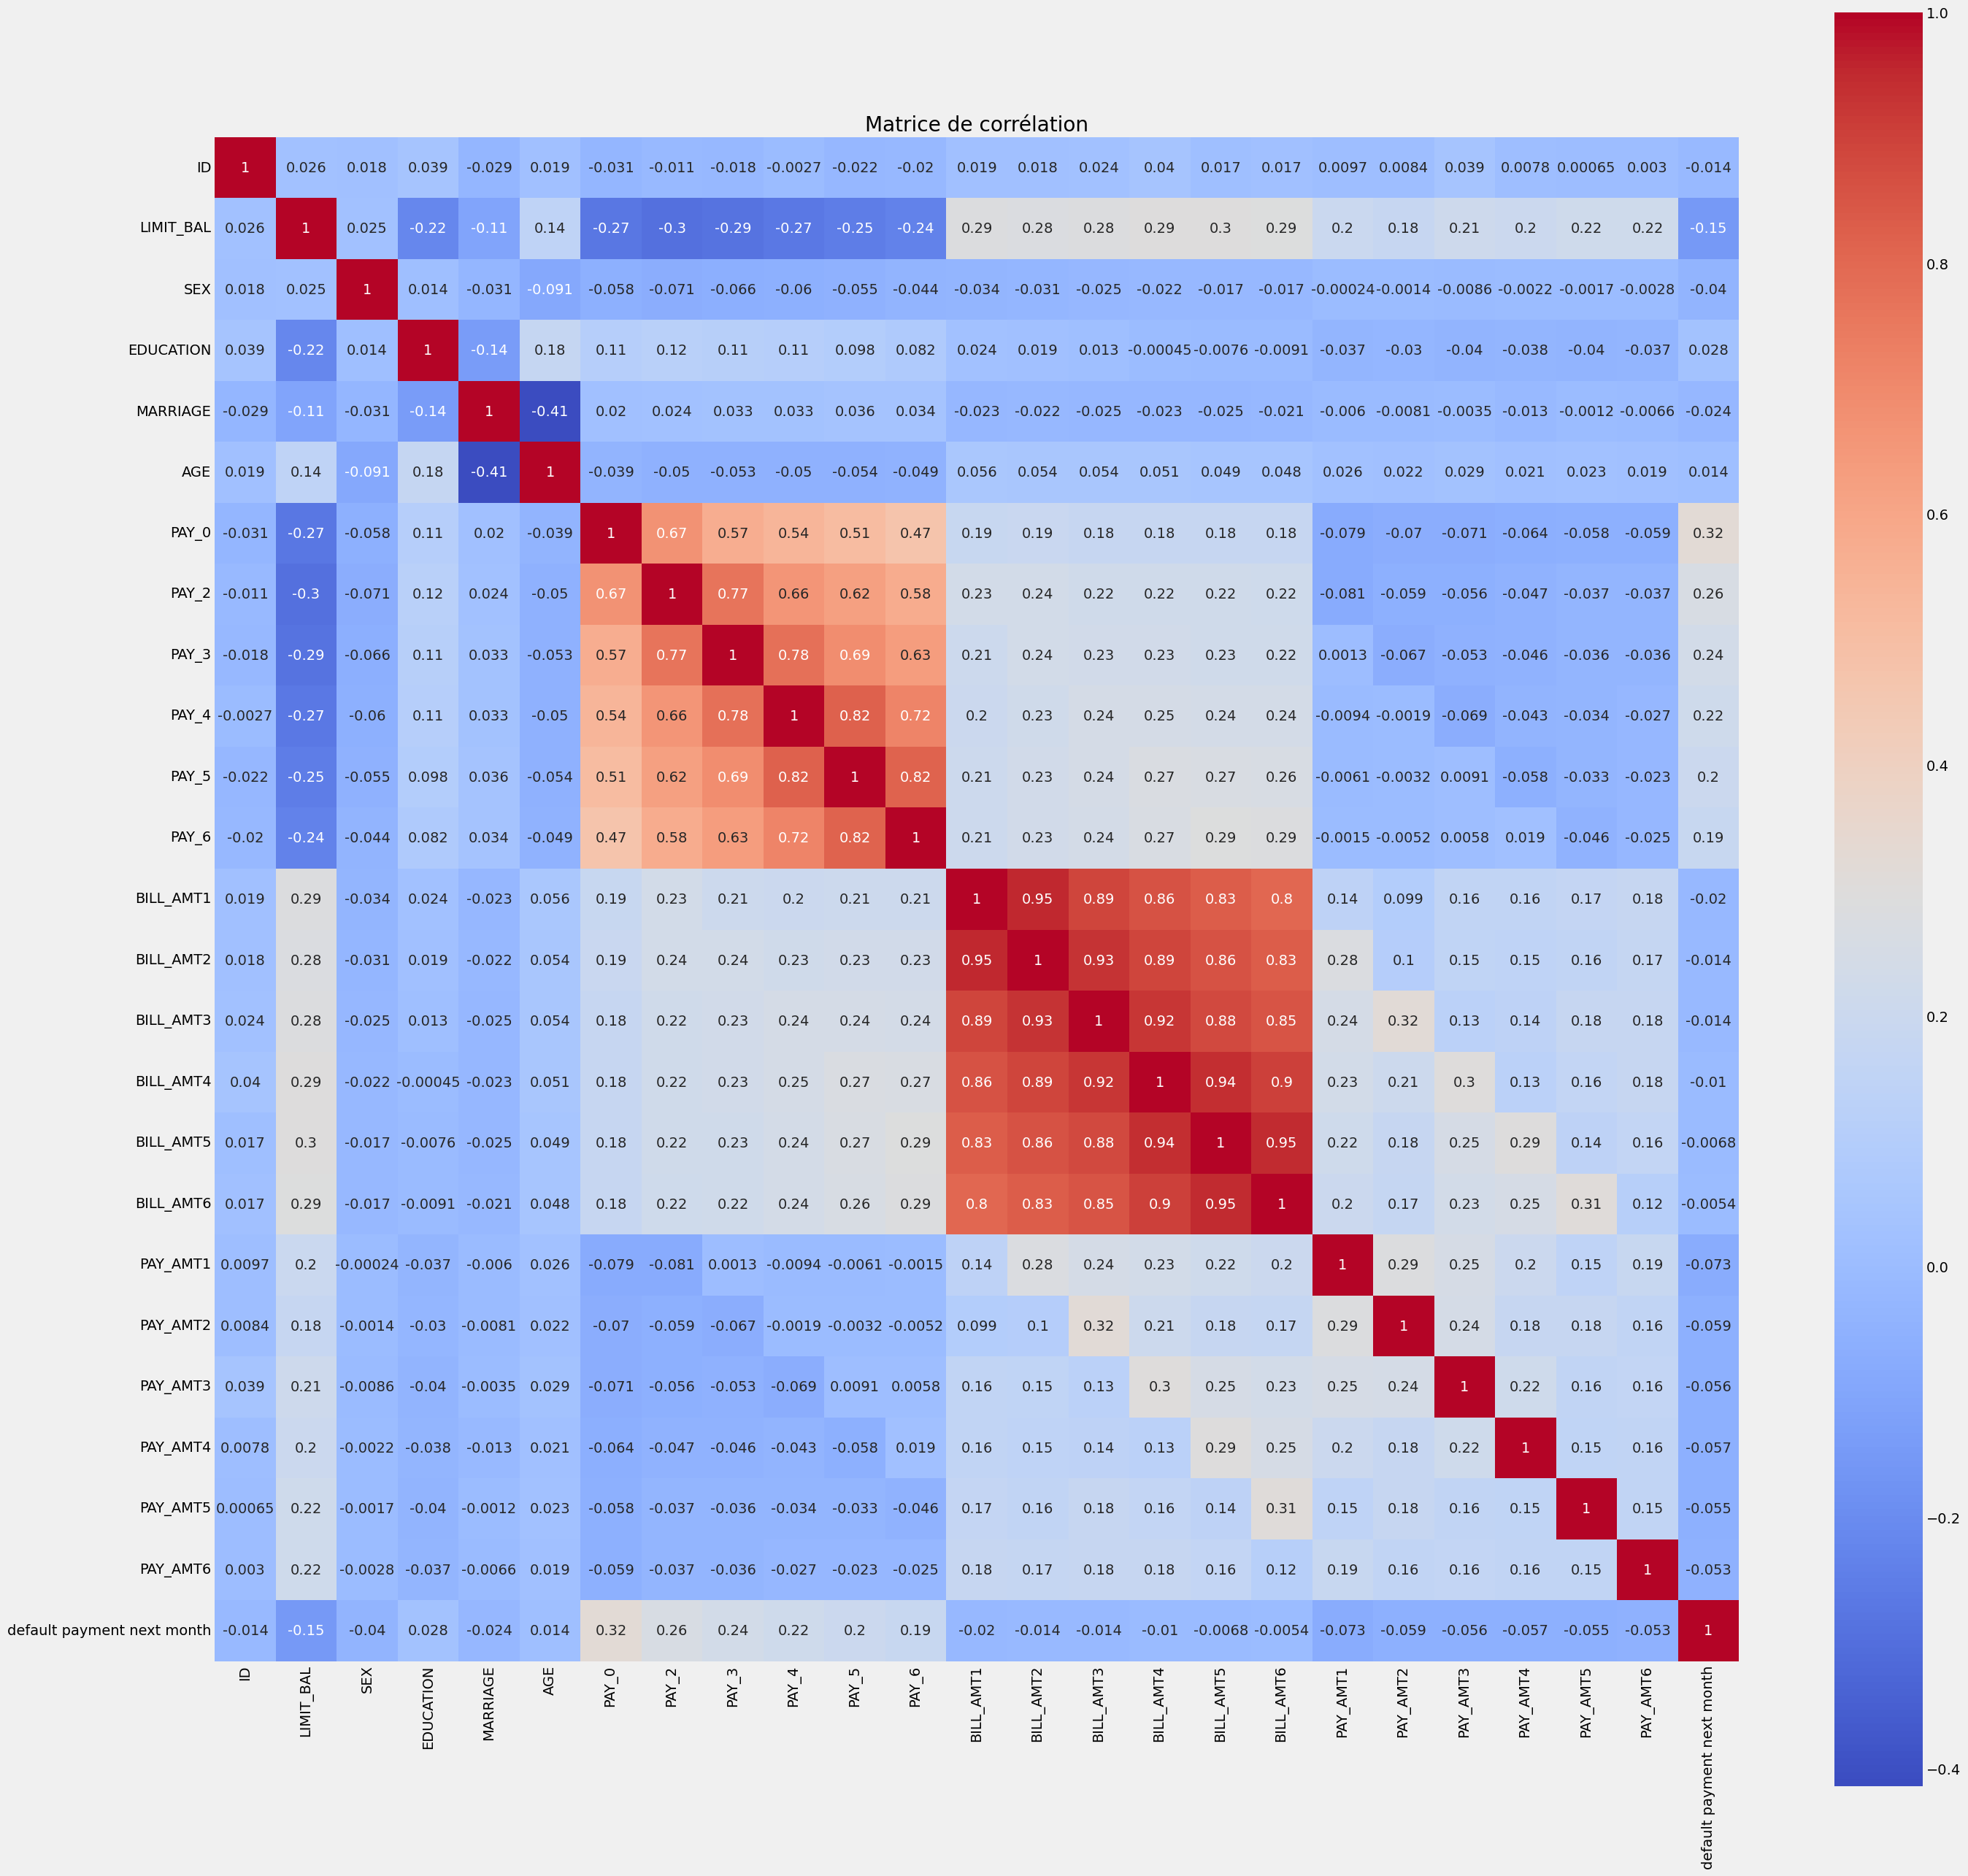

In [56]:
# Matrice de corrélation
corrmat = df.corr(numeric_only=True)
plt.figure(figsize=(30,30))
sns.heatmap(corrmat, cmap='coolwarm', square=True,annot = True)
plt.title("Matrice de corrélation")


### Interprétation
L'analyse montre une très forte corrélation (entre 0.80 et 0.95) entre les montants des factures (BILL_AMT1 à BILL_AMT6). Cela indique que les montants facturés sur des mois consécutifs évoluent de manière similaire et traduisent le niveau d'endettement du client. De plus ces variables Bill_AMT sont aussi corrélées avec les variables Pay_AMT car les clients bénéficiant d'une limite de crédit élevée réalisent souvent des dépenses plus importantes.

De même, les statuts de paiement (PAY_0 à PAY_6) sont fortement corrélés entre eux (entre 0.47 et 0.82), indiquant qu'un client en retard de paiement un mois donné a tendance à l'être aussi les mois qui suivent. Enfin, on observe une corrélation négative de -0.41 entre l'âge et le statut marital, confirmant logiquement que les clients plus âgés sont plus souvent mariés.

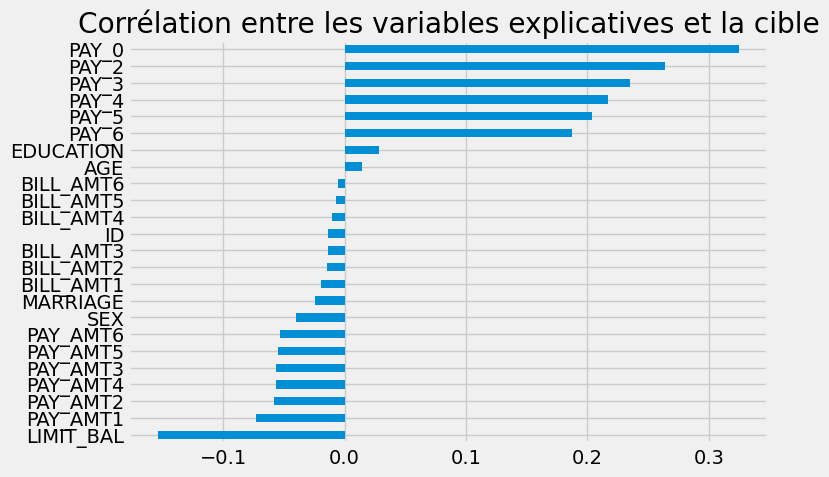

In [57]:
plt.rcParams["figure.figsize"] = (8, 5)
corrmat['default payment next month'].sort_values(ascending=True)[:-1].plot(kind='barh')
plt.title("Corrélation entre les variables explicatives et la cible")
plt.tight_layout()
plt.show()

Les variables d'historique de paiement (PAY_0 à PAY_6) sont les plus prédictives, avec une corrélation positive qui s'accentue à mesure qu'on se rapproche de l'échéance, passant de 0.19 en avril (PAY_6) à 0.32 en septembre (PAY_0). 

À l'inverse, la limite de crédit (LIMIT_BAL) présente une corrélation négative de -0.15, ce qui montre que les clients ayant de gros crédits font statistiquement moins de défauts. Pour finir, les variables socio-démographiques comme le sexe, l'âge, l'éducation ou le mariage ont des corrélations proches de zéro, ce qui signifie qu'elles n'ont pas d'impact linéaire direct sur le risque de défaut.

Visualisation variables numériques vs cible

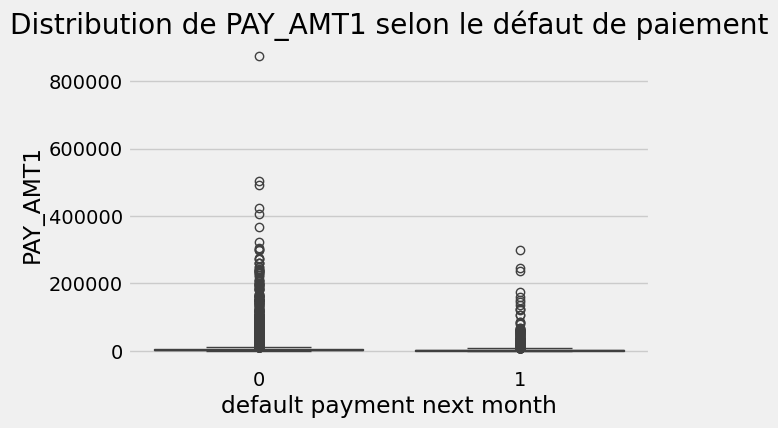

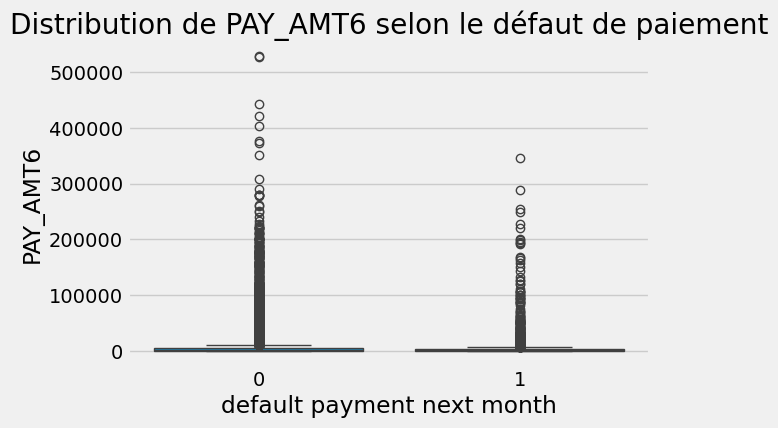

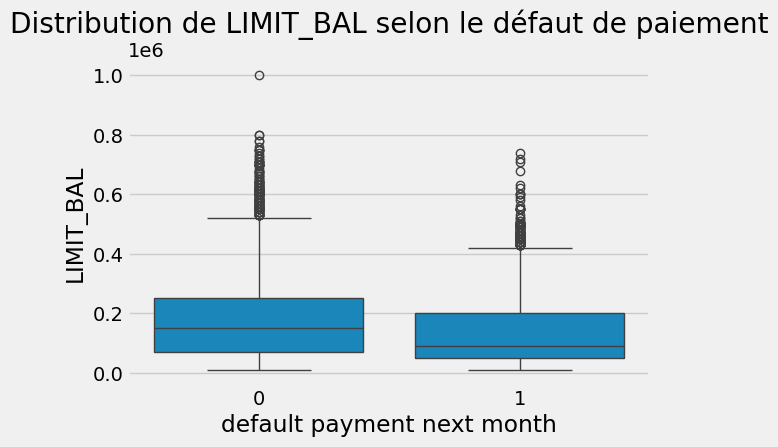

In [58]:
var_numeric = ['PAY_AMT1','PAY_AMT6','LIMIT_BAL']
for col in var_numeric: 
    plt.figure(figsize=(6,4))
    sns.boxplot(x="default payment next month",y=col,data=df)
    plt.title(f"Distribution de {col} selon le défaut de paiement")

Les distributions de PAY_AMT1 et PAY_AMT6 affichent un comportement très similaire. Pour les deux classes (0 et 1), la grande majorité des paiements est concentrée près de zéro, ce qui rend les boîtes très écrasées. Cependant, on observe une présence beaucoup plus importante de valeurs aberrantes (les points individuels très hauts) chez les clients qui ne font pas défaut (classe 0). Cela indique que les clients qui effectuent de très gros paiements ponctuels basculent statistiquement beaucoup moins en défaut de paiement.

Le graphique montre que les clients qui ne font pas défaut (classe 0) ont globalement une limite de crédit plus élevée que ceux en défaut de paiement (classe 1). La boîte de la classe 0 est positionnée plus haut, avec une médiane proche de 150 000 NT$, tandis que celle de la classe 1 se situe en dessous de 100 000 NT$. Cela confirme l'existence d'une relation négative : les profils jugés plus risqués reçoivent des limites de crédit plus faibles de la part de la banque.

Visualisation variables catégorielles vs cible

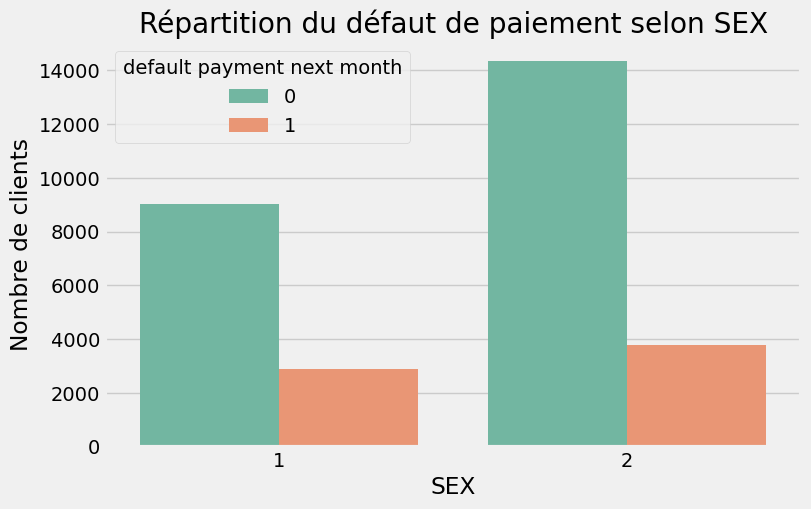

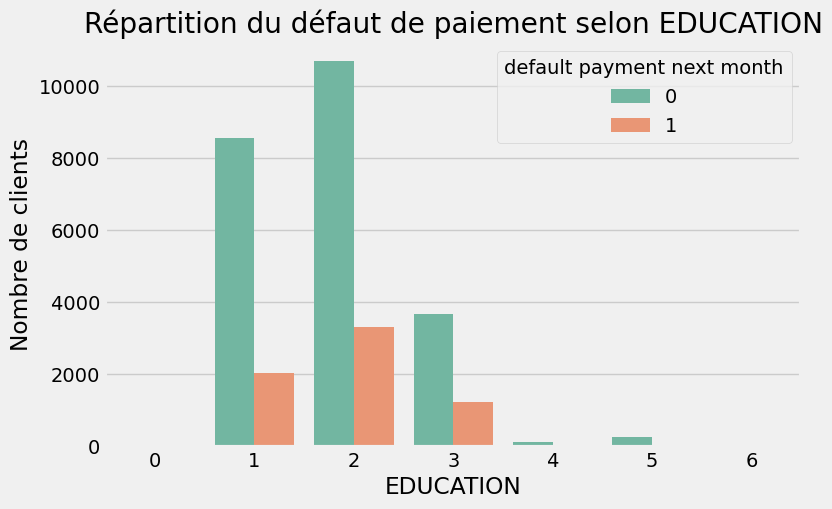

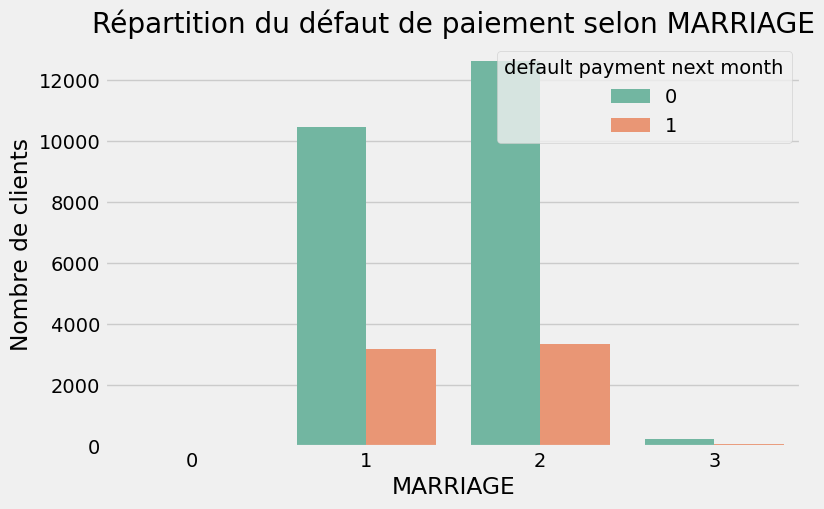

In [59]:
var_cat = ['SEX', 'EDUCATION', 'MARRIAGE']

for col in var_cat:
    plt.figure(figsize=(8, 5))
    # Le paramètre 'hue' permet de ventiler chaque catégorie selon la cible (0 ou 1)
    sns.countplot(x=col, hue='default payment next month', data=df, palette='Set2')
    plt.title(f"Répartition du défaut de paiement selon {col}")
    plt.ylabel("Nombre de clients")


Commentaire

L'analyse des proportions montre que le risque de défaut de paiement varie selon le profil des clients, même si les volumes globaux peuvent être trompeurs. On observe que les hommes (SEX = 1) présentent un taux de défaut légèrement plus élevé que les femmes, avec environ 25% de clients en échec contre 22%. Du côté de la situation matrimoniale, les personnes mariées (MARRIAGE = 1) affichent également une proportion de défaut légèrement supérieure à celle des célibataires. Enfin, concernant le niveau d'études (EDUCATION), ce sont les clients ayant un niveau d'études secondaires (catégorie 3) qui présentent la part de défaut de paiement la plus importante par rapport à leur effectif total.

Pré Traitement

ID                            0.0
PAY_AMT5                      0.0
PAY_AMT4                      0.0
PAY_AMT3                      0.0
PAY_AMT2                      0.0
PAY_AMT1                      0.0
BILL_AMT6                     0.0
BILL_AMT5                     0.0
BILL_AMT4                     0.0
BILL_AMT3                     0.0
BILL_AMT2                     0.0
PAY_AMT6                      0.0
BILL_AMT1                     0.0
PAY_5                         0.0
PAY_4                         0.0
PAY_3                         0.0
PAY_2                         0.0
PAY_0                         0.0
AGE                           0.0
MARRIAGE                      0.0
EDUCATION                     0.0
SEX                           0.0
LIMIT_BAL                     0.0
PAY_6                         0.0
default payment next month    0.0
dtype: float64


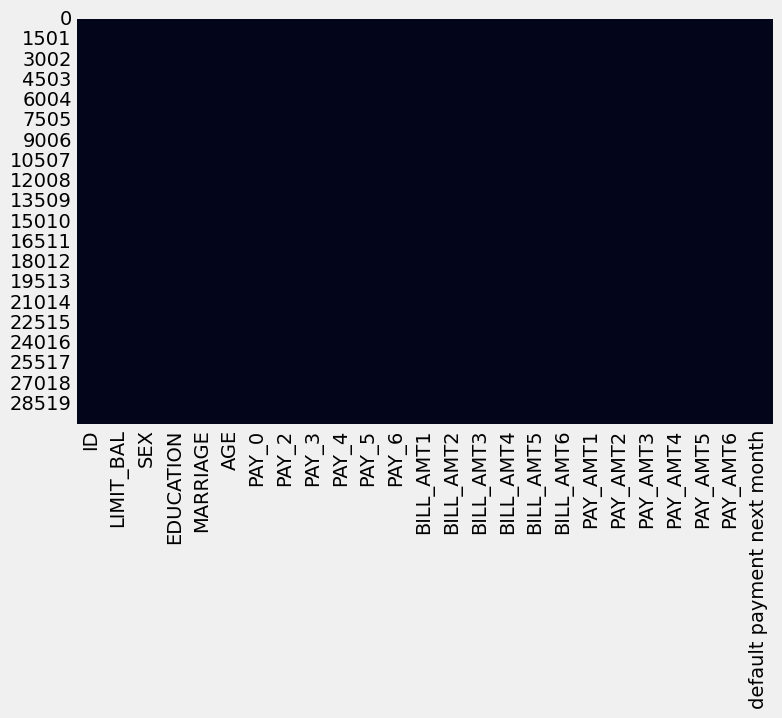

In [60]:
missing_data = df.isna()
sns.heatmap(missing_data,cbar=False)
# Pourcentage des valeurs manquantes
miss_rates = (missing_data.sum() /df.shape[0])*100
# Trie dans l'ordre croissant
miss_rates = miss_rates.sort_values(ascending=True)
print(miss_rates)

Comme souligné dans la description du problème, il n'y a aucune donnée manquante. 

In [61]:
data_clean = df.drop('ID',axis=1)
data_clean.head(3)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


Pour les variables PAY_0 à PAY_6, nous choisissons de les traiter comme des variables numériques ordonnées. Comme il y a une notion d'intensité dans le retard de paiement (plus le chiffre est grand, plus le retard est important), nous allons simplement les normaliser à l'aide d'un StandardScaler dans notre pipeline, à l'exception du cas où nous testerions une régression logistique, pour laquelle un OneHotEncoder pourrait être testé afin de mieux séparer les codes négatifs (-1, -2).

Nous avons commencé par un modèle de référence simple (régression logistique), avant d'explorer des modèles plus complexes et des stratégies de prétraitement plus avancées.

In [62]:
X = data_clean.drop("default payment next month",  axis=1)

y = data_clean["default payment next month"]
# Vérification des dimensions du dtaframe
print(X.shape)
print(y.shape)
print(data_clean.shape)

(30000, 23)
(30000,)
(30000, 24)


Séparation des données en train et test sets

In [63]:
# 70% train / 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 15% val / 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

Ré utilisation de la fonction de pré traitement pour passer à l'entrainement du modèle sur la régression logistique

In [64]:
preprocessor = build_logistic_preprocessor()

Construction de la pipeline pour un modèle de régression logistique

In [65]:
model = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000, random_state=42)
)

Entrainement et métriques du modèle

In [66]:
reg_log_simple = train_and_evaluate(model,X_train,y_train,X_test,y_test)

--------- Métriques pour TRAIN ---------
              precision    recall  f1-score   support

           0       0.82      0.97      0.89     16355
           1       0.72      0.26      0.38      4645

    accuracy                           0.81     21000
   macro avg       0.77      0.61      0.63     21000
weighted avg       0.80      0.81      0.78     21000

--------- Métriques pourTEST ---------
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      3504
           1       0.71      0.24      0.35       996

    accuracy                           0.81      4500
   macro avg       0.76      0.60      0.62      4500
weighted avg       0.79      0.81      0.77      4500



Matrice de confusion sur le train set

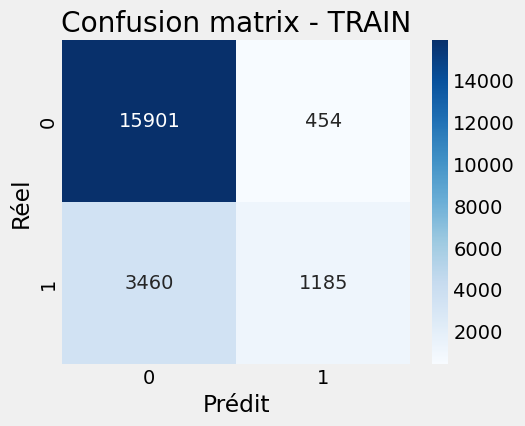

In [67]:
y_pred_train = model.predict(X_train)
cm_train = plot_confusion_matrix(y_train, y_pred_train, title="Confusion matrix - TRAIN")

Comparaison des résultats sur les ensembles de train et test

On remarque que le modèle a des performance similaires sur le train set et le test set. En effet, on observe une precision assez importante (0.82) pour la classe 0 (absence de défautd e paiement) aussi bien sur le train que sur le test set. Cependant, les recall sont assez faible sur la classe 1 (défaut de paiement) ce qui se traduit par une importante quantité de faux négatifs qui correspondent à des prédictions pour lesquelles les clients sont en défaut de paiement mais classés dans la classe 0. Donc notre but est d'améliorer ce modèle en vue d'augmenter le plus le recall qui est la métrique la plus importante pour la banque qui ne souhaite pas faire faillite. 

Voyons voir si on ajoute le paramètre balanced

In [68]:
model_2 = make_pipeline(
    preprocessor,
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
)

In [69]:
reg_log_balanced = train_and_evaluate(model_2,X_train,y_train,X_test,y_test)

--------- Métriques pour TRAIN ---------
              precision    recall  f1-score   support

           0       0.88      0.70      0.78     16355
           1       0.38      0.65      0.48      4645

    accuracy                           0.69     21000
   macro avg       0.63      0.68      0.63     21000
weighted avg       0.77      0.69      0.71     21000

--------- Métriques pourTEST ---------
              precision    recall  f1-score   support

           0       0.87      0.70      0.77      3504
           1       0.37      0.64      0.47       996

    accuracy                           0.68      4500
   macro avg       0.62      0.67      0.62      4500
weighted avg       0.76      0.68      0.71      4500



Matrice de confusion sur le test set

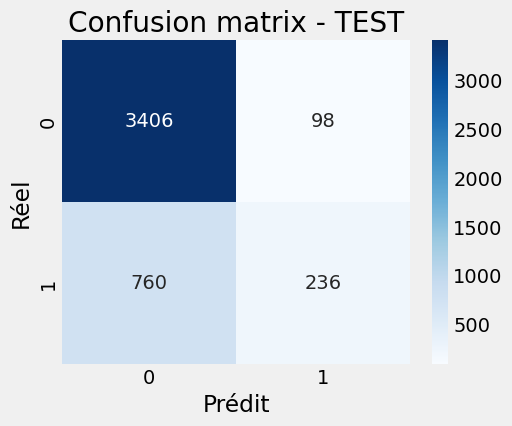

In [70]:
y_pred_test = model.predict(X_test)
cm_test = plot_confusion_matrix(y_test, y_pred_test, title="Confusion matrix - TEST")

In [71]:
reg_log_balanced = train_and_evaluate(model_2,X_train,y_train,X_test,y_test)

--------- Métriques pour TRAIN ---------
              precision    recall  f1-score   support

           0       0.88      0.70      0.78     16355
           1       0.38      0.65      0.48      4645

    accuracy                           0.69     21000
   macro avg       0.63      0.68      0.63     21000
weighted avg       0.77      0.69      0.71     21000

--------- Métriques pourTEST ---------
              precision    recall  f1-score   support

           0       0.87      0.70      0.77      3504
           1       0.37      0.64      0.47       996

    accuracy                           0.68      4500
   macro avg       0.62      0.67      0.62      4500
weighted avg       0.76      0.68      0.71      4500




L’utilisation du paramètre class_weight="balanced" améliore significativement la détection des clients en défaut de paiement, avec une augmentation du recall de la classe 1. Toutefois, cette amélioration s’accompagne d’une baisse de la précision, entraînant davantage de faux positifs.

Dans ce contexte, le F1-score constitue une métrique pertinente car il permet de trouver un compromis entre précision et rappel. L’objectif est donc d’optimiser ce compromis tout en tenant compte des coûts métier associés aux erreurs de classification.

RESULTATS BONS DANS LA GESTION DE RISQUE : contexte métier ici

L'activation du mode class_weight='balanced' illustre parfaitement le compromis entre Précision et Recall. Bien que la précision pour la classe 1 diminue légèrement à 37 % (entraînant davantage de fausses alertes), le Recall augmente de façon spectaculaire pour atteindre 64 % sur le jeu de test. >
D'un point de vue métier, ce modèle est largement préférable car il permet de détecter la majorité des clients en défaut de paiement. Cette amélioration globale est confirmée par le F1-score de la classe 1, qui progresse nettement en passant de 0.35 à 0.47.

Le seuil de classification par défaut (0.5) n’est pas adapté au déséquilibre des classes. Nous optimisons donc ce seuil sur le jeu de validation afin de maximiser la métrique F1-score (ou recall selon l’objectif métier), permettant un meilleur compromis entre détection des défauts et limitation des faux positifs.

In [72]:
y_val_proba = model.predict_proba(X_val)[:, 1]

In [73]:

thresholds = np.linspace(0.1, 0.9, 81)

best_threshold = 0.5
best_score = 0

for t in thresholds:
    y_pred = (y_val_proba >= t).astype(int)

    score = f1_score(y_val, y_pred)  # ou recall_score selon objectif

    if score > best_score:
        best_score = score
        best_threshold = t

print("Meilleur seuil :", best_threshold)
print("Meilleur score val :", best_score)

Meilleur seuil : 0.28
Meilleur score val : 0.5081194342587743


Le seuil optimal de classification n’est pas 0.5 mais 0.28, ce qui confirme le déséquilibre des classes. L’abaissement du seuil permet d’augmenter la détection des défauts de paiement, au prix d’une hausse des faux positifs. Le compromis retenu maximise le F1-score sur le jeu de validation.

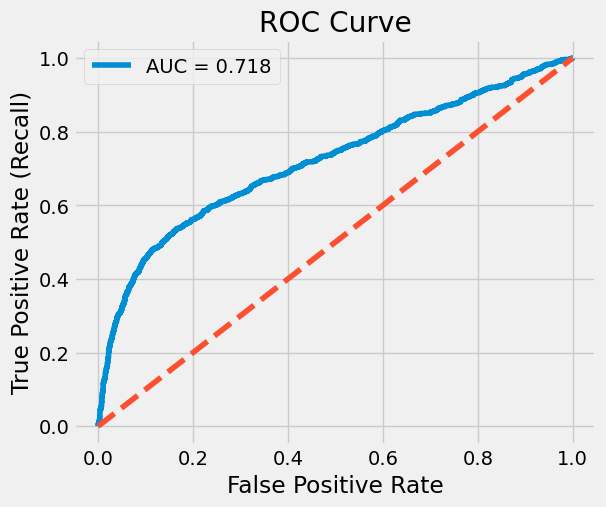

In [74]:
y_test_proba =  model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc_score = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # baseline aléatoire

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

L'obtention d'une AUC de 0.718 montre que le modèle parvient à prédire de manière correcte les clients à risque de ceux solvables.

Dans la suite nous allons tester, entrainer d'autres modèles histoire de comparer les performances de chacun pour choisir le meilleur susceptible d'estimer avec précision la probabilité réelle de défaut.

Avant on va essayer un autre pré traitement avec RobustScaler pour traiter les variables catégorielles plutôt que StandarScaler

In [75]:
preprocessor_robust = build_robust_preprocessor()

In [76]:
model_robust = make_pipeline(preprocessor_robust,LogisticRegression(max_iter=1000, random_state=42))

In [77]:
reg_logrobust =  train_and_evaluate(model_robust,X_train,y_train,X_test,y_test)

--------- Métriques pour TRAIN ---------
              precision    recall  f1-score   support

           0       0.82      0.97      0.89     16355
           1       0.72      0.25      0.38      4645

    accuracy                           0.81     21000
   macro avg       0.77      0.61      0.63     21000
weighted avg       0.80      0.81      0.78     21000

--------- Métriques pourTEST ---------
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      3504
           1       0.71      0.24      0.35       996

    accuracy                           0.81      4500
   macro avg       0.76      0.60      0.62      4500
weighted avg       0.79      0.81      0.77      4500



Les rapports de classification montrent que le modèle ne sur-apprenp pas (overfitting), car les performances sur le jeu de test (Accuracy de 0.81, F1-score de 0.35) restent très proches de celles du jeu d'entraînement. Cependant, le modèle peine fortement à prédire la classe minoritaire (1) avec un recall très faible de 24 %.

De plus, l'utilisation du RobustScaler à la place du StandardScaler fournit des métriques strictement identiques. Cela indique que le jeu de données ne contient pas de valeurs aberrantes extrêmes capables d'influencer négativement le comportement de la régression logistique.